In [202]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [159]:
# Dataset sintético desbalanceado
X, y = make_classification(
    n_samples=1200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.90, 0.05],
    class_sep=1.0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Distribución train:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución test :", dict(zip(*np.unique(y_test, return_counts=True))))

Train shape: (840, 2)
Test shape : (360, 2)
Distribución train: {np.int64(0): np.int64(772), np.int64(1): np.int64(68)}
Distribución test : {np.int64(0): np.int64(331), np.int64(1): np.int64(29)}


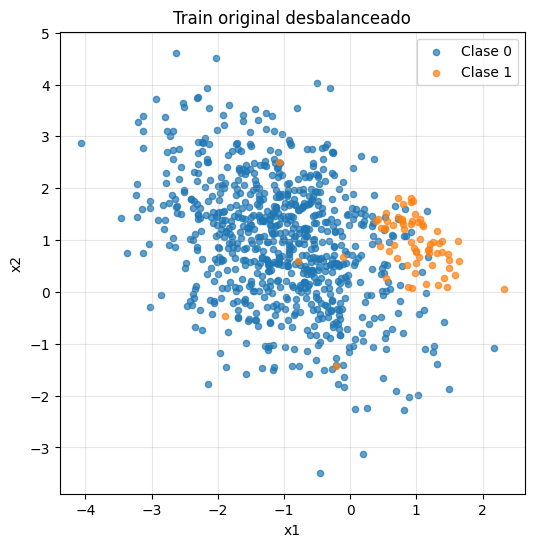

In [160]:
def plot_dataset(X, y, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=20, alpha=0.7, label="Clase 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=20, alpha=0.7, label="Clase 1")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_dataset(X_train, y_train, "Train original desbalanceado")

## Entrenamiento normal

In [161]:
def evaluate_model(model, X_train, y_train, X_test, y_test, title="Modelo"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"{title} ====== ")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(title)
    plt.show()

Baseline ====== 
              precision    recall  f1-score   support

           0     0.9672    0.9789    0.9730       331
           1     0.7200    0.6207    0.6667        29

    accuracy                         0.9500       360
   macro avg     0.8436    0.7998    0.8198       360
weighted avg     0.9473    0.9500    0.9483       360



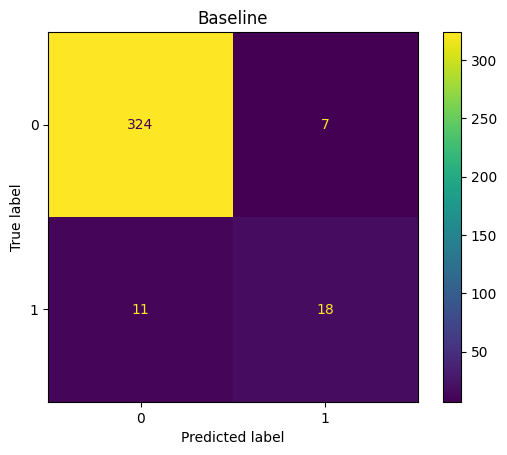

In [162]:
baseline_model = LogisticRegression()
evaluate_model(
    baseline_model,
    X_train, y_train,
    X_test, y_test,
    title="Baseline"
)

## Random Undersampling

In [163]:
def random_undersample(X, y, random_state=42):
    rng = np.random.default_rng(random_state)

    classes, counts = np.unique(y, return_counts=True)
    minority_class = classes[np.argmin(counts)]
    majority_class = classes[np.argmax(counts)]

    minority_idx = np.where(y == minority_class)[0]
    majority_idx = np.where(y == majority_class)[0]

    sampled_majority_idx = rng.choice(
        majority_idx,
        size=len(minority_idx),
        replace=False
    )

    selected_idx = np.concatenate([minority_idx, sampled_majority_idx])
    rng.shuffle(selected_idx)

    return X[selected_idx], y[selected_idx]

In [164]:
X_under, y_under = random_undersample(X_train, y_train, random_state=42)

print("Distribución original :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución balanceada:", dict(zip(*np.unique(y_under, return_counts=True))))

Distribución original : {np.int64(0): np.int64(772), np.int64(1): np.int64(68)}
Distribución balanceada: {np.int64(0): np.int64(68), np.int64(1): np.int64(68)}


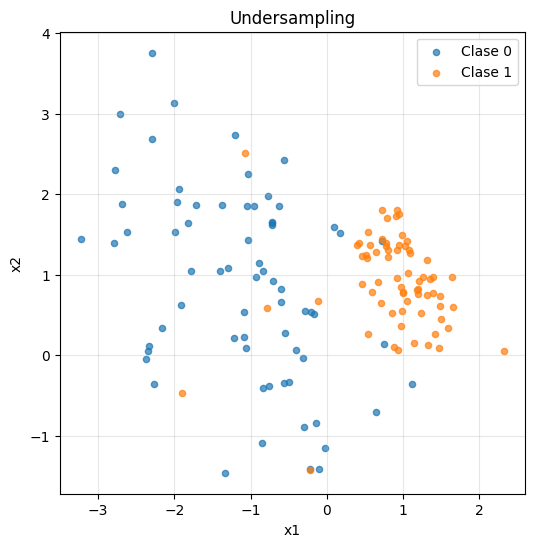

In [165]:
plot_dataset(X_under, y_under, "Undersampling")

Random Undersampling ====== 
              precision    recall  f1-score   support

           0     0.9933    0.8973    0.9429       331
           1     0.4426    0.9310    0.6000        29

    accuracy                         0.9000       360
   macro avg     0.7180    0.9142    0.7714       360
weighted avg     0.9490    0.9000    0.9152       360



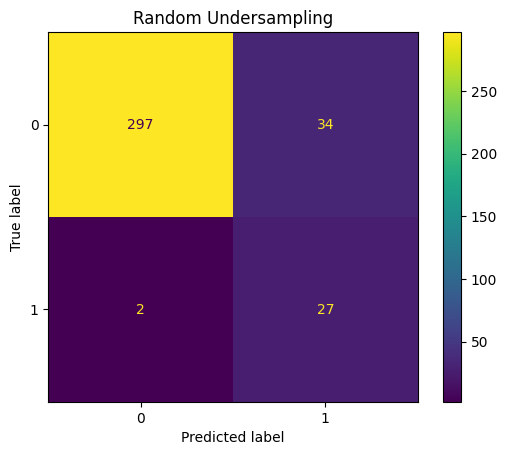

In [166]:
under_model = LogisticRegression()
evaluate_model(
    under_model,
    X_under, y_under,
    X_test, y_test,
    title="Random Undersampling"
)

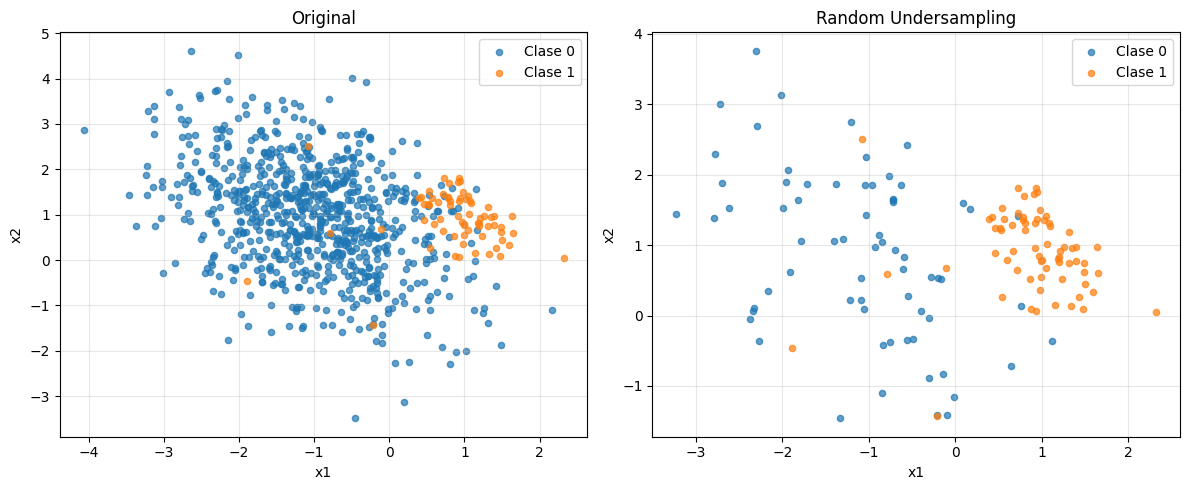

In [167]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Original")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_under[y_under == 0, 0], X_under[y_under == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_under[y_under == 1, 0], X_under[y_under == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Random Undersampling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Tomek Links

In [168]:
def find_tomek_links(X, y):
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X)

    distances, indices = nn.kneighbors(X)
    nearest_neighbor = indices[:, 1]

    tomek_pairs = []

    for i in range(len(X)):
        j = nearest_neighbor[i]

        if nearest_neighbor[j] == i and y[i] != y[j]:
            if i < j:
                tomek_pairs.append((i, j))

    return tomek_pairs

In [169]:
tomek_pairs = find_tomek_links(X_train, y_train)
print("Cantidad de Tomek Links encontrados:", len(tomek_pairs))
print("Primeros pares:", tomek_pairs[:10])

Cantidad de Tomek Links encontrados: 13
Primeros pares: [(1, np.int64(146)), (29, np.int64(428)), (31, np.int64(269)), (43, np.int64(464)), (47, np.int64(680)), (112, np.int64(253)), (153, np.int64(521)), (164, np.int64(482)), (231, np.int64(356)), (272, np.int64(783))]


In [170]:
def remove_tomek_links(X, y):
    tomek_pairs = find_tomek_links(X, y)

    classes, counts = np.unique(y, return_counts=True)
    majority_class = classes[np.argmax(counts)]

    to_remove = set()

    for i, j in tomek_pairs:
        if y[i] == majority_class:
            to_remove.add(i)
        if y[j] == majority_class:
            to_remove.add(j)

    keep_mask = np.ones(len(X), dtype=bool)
    keep_mask[list(to_remove)] = False

    return X[keep_mask], y[keep_mask], tomek_pairs, to_remove

In [171]:
X_tomek, y_tomek, tomek_pairs, removed_idx = remove_tomek_links(X_train, y_train)

print("Distribución original :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución tras Tomek:", dict(zip(*np.unique(y_tomek, return_counts=True))))
print("Cantidad eliminada:", len(removed_idx))

Distribución original : {np.int64(0): np.int64(772), np.int64(1): np.int64(68)}
Distribución tras Tomek: {np.int64(0): np.int64(759), np.int64(1): np.int64(68)}
Cantidad eliminada: 13


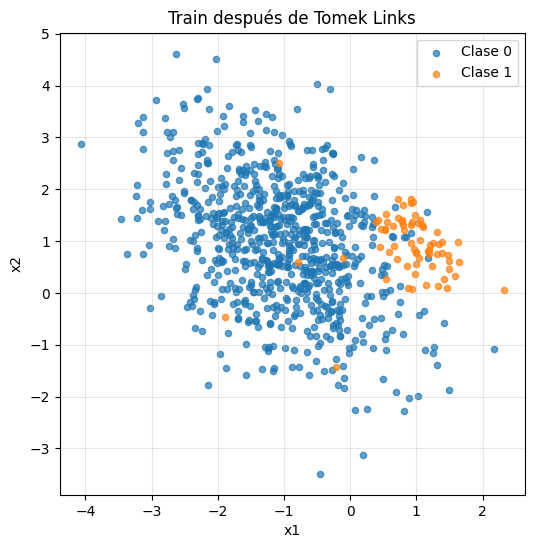

In [172]:
plot_dataset(X_tomek, y_tomek, "Train después de Tomek Links")

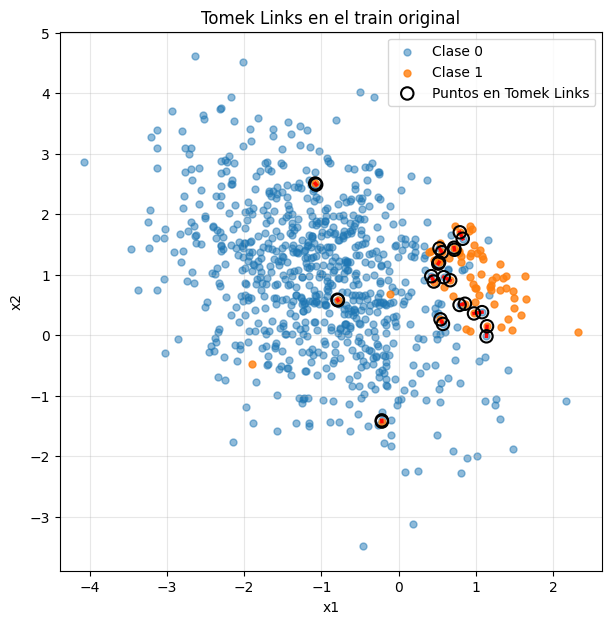

In [173]:
def plot_tomek_links(X, y, tomek_pairs, title="Tomek Links"):
    plt.figure(figsize=(7, 7))

    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=25, alpha=0.5, label="Clase 0", zorder=1)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=25, alpha=0.8, label="Clase 1", zorder=2)

    for i, j in tomek_pairs:
        plt.plot(
            [X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]],
            'r-',
            linewidth=2.5,
            alpha=0.95,
            zorder=3
        )

    if len(tomek_pairs) > 0:
        idx = np.unique(np.array(tomek_pairs).flatten())
        plt.scatter(
            X[idx, 0], X[idx, 1],
            s=80,
            facecolors='none',
            edgecolors='black',
            linewidths=1.5,
            label="Puntos en Tomek Links",
            zorder=4
        )

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_tomek_links(X_train, y_train, tomek_pairs, "Tomek Links en el train original")

Tomek Links ====== 
              precision    recall  f1-score   support

           0     0.9730    0.9789    0.9759       331
           1     0.7407    0.6897    0.7143        29

    accuracy                         0.9556       360
   macro avg     0.8569    0.8343    0.8451       360
weighted avg     0.9543    0.9556    0.9548       360



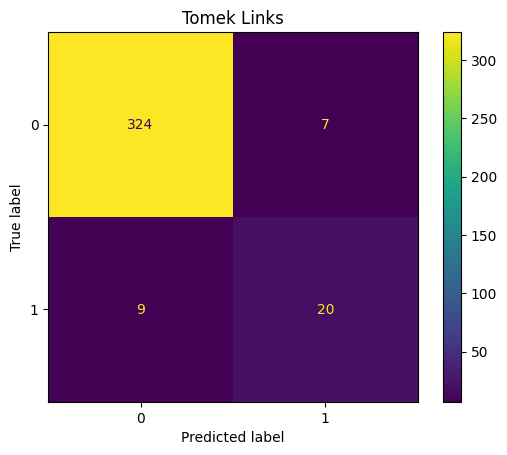

In [174]:
tomek_model = LogisticRegression()
evaluate_model(
    tomek_model,
    X_tomek, y_tomek,
    X_test, y_test,
    title="Tomek Links"
)

In [175]:
models = {
    "Baseline": (X_train, y_train),
    "Undersampling": (X_under, y_under),
    "Tomek Links": (X_tomek, y_tomek)
}

for name, (Xtr, ytr) in models.items():
    print("\n" + "=" * 60)
    model = LogisticRegression()
    model.fit(Xtr, ytr)
    y_pred = model.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred, digits=4))


Baseline
              precision    recall  f1-score   support

           0     0.9672    0.9789    0.9730       331
           1     0.7200    0.6207    0.6667        29

    accuracy                         0.9500       360
   macro avg     0.8436    0.7998    0.8198       360
weighted avg     0.9473    0.9500    0.9483       360


Undersampling
              precision    recall  f1-score   support

           0     0.9933    0.8973    0.9429       331
           1     0.4426    0.9310    0.6000        29

    accuracy                         0.9000       360
   macro avg     0.7180    0.9142    0.7714       360
weighted avg     0.9490    0.9000    0.9152       360


Tomek Links
              precision    recall  f1-score   support

           0     0.9730    0.9789    0.9759       331
           1     0.7407    0.6897    0.7143        29

    accuracy                         0.9556       360
   macro avg     0.8569    0.8343    0.8451       360
weighted avg     0.9543    0.9556   

## Imbalanced-learn

In [176]:
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

#### Random undersampling

In [177]:
rus = RandomUnderSampler(random_state=42)
X_under_lib, y_under_lib = rus.fit_resample(X_train, y_train)

print("Distribución original :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución balanceada:", dict(zip(*np.unique(y_under_lib, return_counts=True))))

Distribución original : {np.int64(0): np.int64(772), np.int64(1): np.int64(68)}
Distribución balanceada: {np.int64(0): np.int64(68), np.int64(1): np.int64(68)}


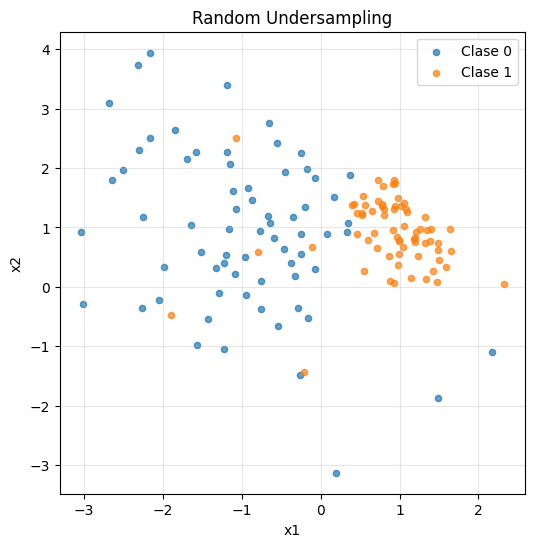

In [178]:
plot_dataset(X_under_lib, y_under_lib, "Random Undersampling")

Random Undersampling ====== 
              precision    recall  f1-score   support

           0     0.9934    0.9124    0.9512       331
           1     0.4821    0.9310    0.6353        29

    accuracy                         0.9139       360
   macro avg     0.7378    0.9217    0.7932       360
weighted avg     0.9522    0.9139    0.9257       360



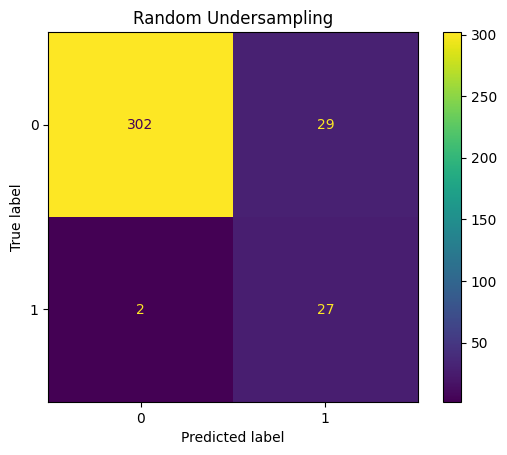

In [179]:
model_under_lib = LogisticRegression()
evaluate_model(
    model_under_lib,
    X_under_lib, y_under_lib,
    X_test, y_test,
    title="Random Undersampling"
)

#### Tomek Links

In [180]:
tl = TomekLinks()
X_tomek_lib, y_tomek_lib = tl.fit_resample(X_train, y_train)

print("Distribución original :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución tras Tomek:", dict(zip(*np.unique(y_tomek_lib, return_counts=True))))

Distribución original : {np.int64(0): np.int64(772), np.int64(1): np.int64(68)}
Distribución tras Tomek: {np.int64(0): np.int64(759), np.int64(1): np.int64(68)}


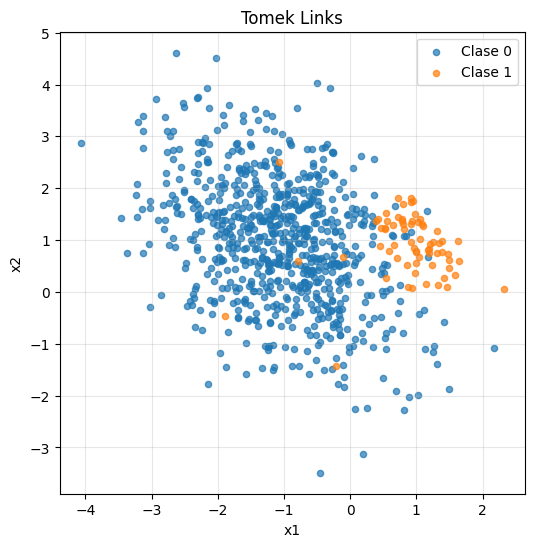

In [181]:
plot_dataset(X_tomek_lib, y_tomek_lib, "Tomek Links")

Tomek Links ====== 
              precision    recall  f1-score   support

           0     0.9730    0.9789    0.9759       331
           1     0.7407    0.6897    0.7143        29

    accuracy                         0.9556       360
   macro avg     0.8569    0.8343    0.8451       360
weighted avg     0.9543    0.9556    0.9548       360



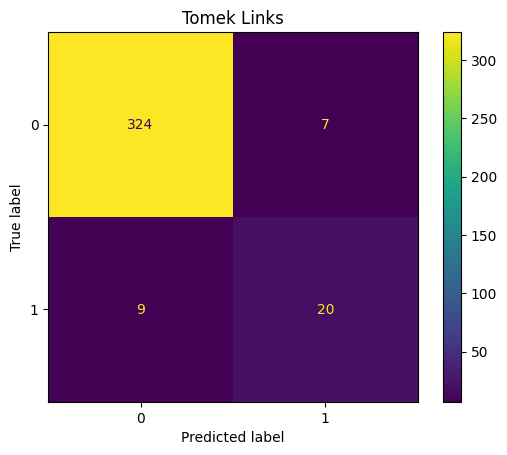

In [182]:
model_tomek_lib = LogisticRegression()
evaluate_model(
    model_tomek_lib,
    X_tomek_lib, y_tomek_lib,
    X_test, y_test,
    title="Tomek Links"
)

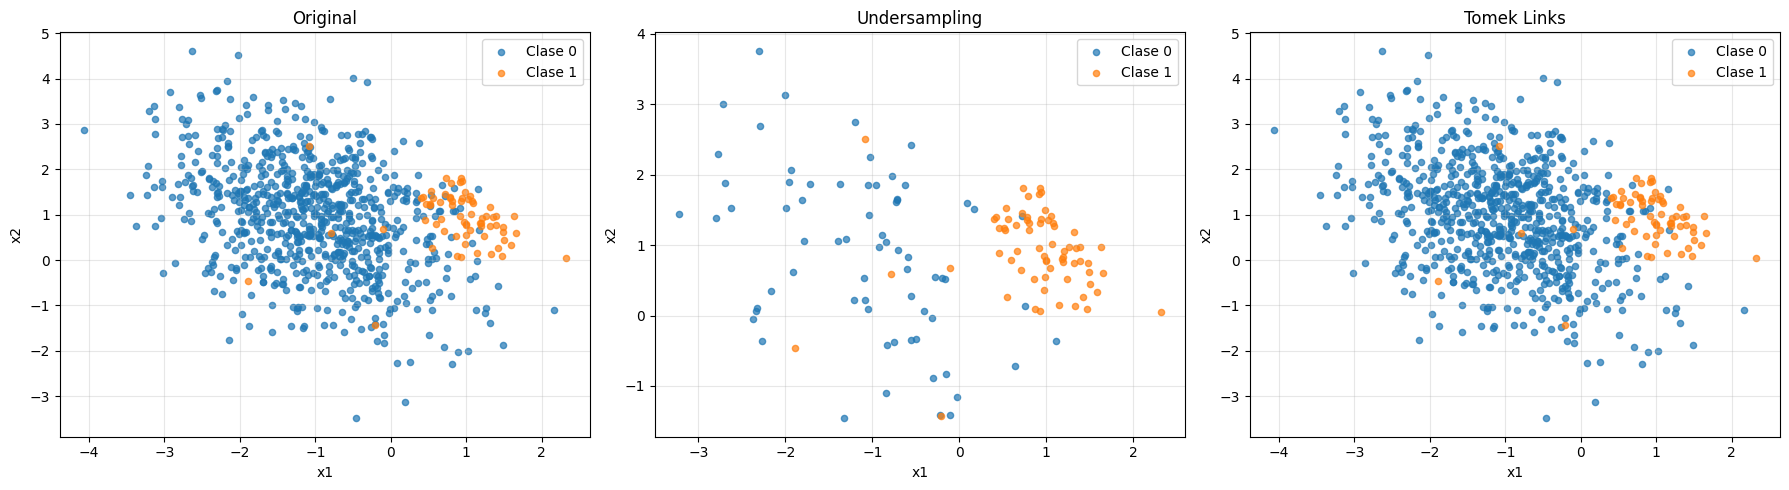

In [183]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Original")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_under[y_under == 0, 0], X_under[y_under == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_under[y_under == 1, 0], X_under[y_under == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Undersampling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(X_tomek[y_tomek == 0, 0], X_tomek[y_tomek == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_tomek[y_tomek == 1, 0], X_tomek[y_tomek == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Tomek Links")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Oversampling

In [184]:
def random_oversample(X, y, random_state=42):
    rng = np.random.default_rng(random_state)

    classes, counts = np.unique(y, return_counts=True)
    minority_class = classes[np.argmin(counts)]
    majority_class = classes[np.argmax(counts)]

    minority_idx = np.where(y == minority_class)[0]
    majority_idx = np.where(y == majority_class)[0]

    n_to_add = len(majority_idx) - len(minority_idx)

    extra_minority_idx = rng.choice(
        minority_idx,
        size=n_to_add,
        replace=True
    )

    selected_idx = np.concatenate([np.arange(len(y)), extra_minority_idx])
    rng.shuffle(selected_idx)

    return X[selected_idx], y[selected_idx]

In [185]:
X_over, y_over = random_oversample(X_train, y_train, random_state=42)

print("Distribución original   :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución balanceada :", dict(zip(*np.unique(y_over, return_counts=True))))

Distribución original   : {np.int64(0): np.int64(772), np.int64(1): np.int64(68)}
Distribución balanceada : {np.int64(0): np.int64(772), np.int64(1): np.int64(772)}


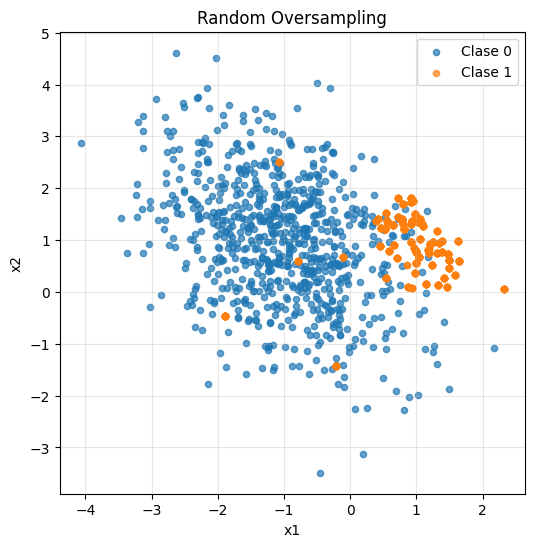

In [186]:
plot_dataset(X_over, y_over, "Random Oversampling")

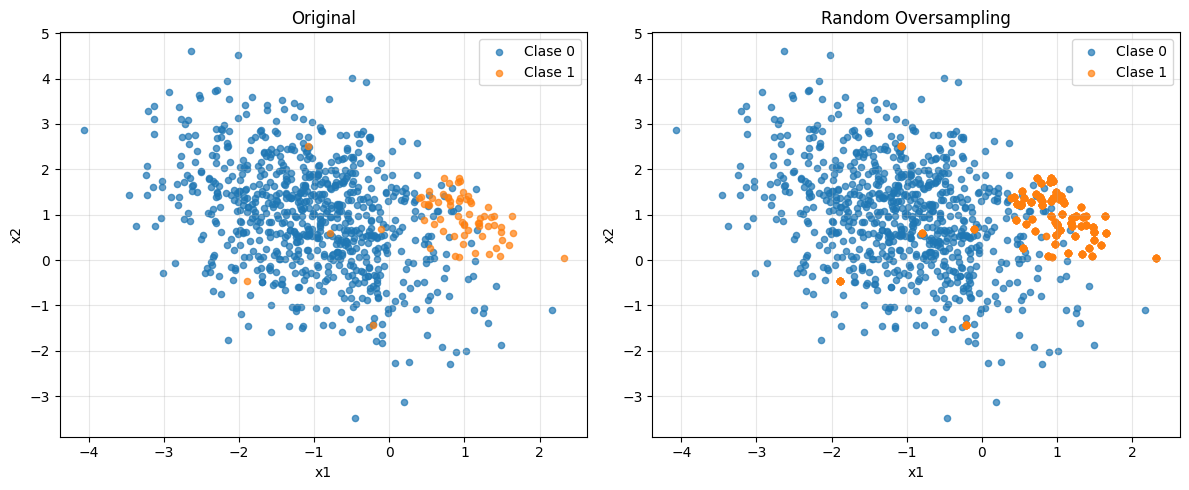

In [187]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Original")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_over[y_over == 0, 0], X_over[y_over == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_over[y_over == 1, 0], X_over[y_over == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Random Oversampling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [188]:
def random_oversample_with_indices(X, y, random_state=42):
    rng = np.random.default_rng(random_state)

    classes, counts = np.unique(y, return_counts=True)
    minority_class = classes[np.argmin(counts)]
    majority_class = classes[np.argmax(counts)]

    minority_idx = np.where(y == minority_class)[0]
    majority_idx = np.where(y == majority_class)[0]

    n_to_add = len(majority_idx) - len(minority_idx)

    extra_minority_idx = rng.choice(
        minority_idx,
        size=n_to_add,
        replace=True
    )

    selected_idx = np.concatenate([np.arange(len(y)), extra_minority_idx])
    rng.shuffle(selected_idx)

    return X[selected_idx], y[selected_idx], extra_minority_idx

In [189]:
X_over2, y_over2, duplicated_idx = random_oversample_with_indices(X_train, y_train, random_state=42)

print("Cantidad de puntos minoritarios duplicados:", len(duplicated_idx))
print("Cantidad de índices minoritarios únicos duplicados:", len(np.unique(duplicated_idx)))

Cantidad de puntos minoritarios duplicados: 704
Cantidad de índices minoritarios únicos duplicados: 68


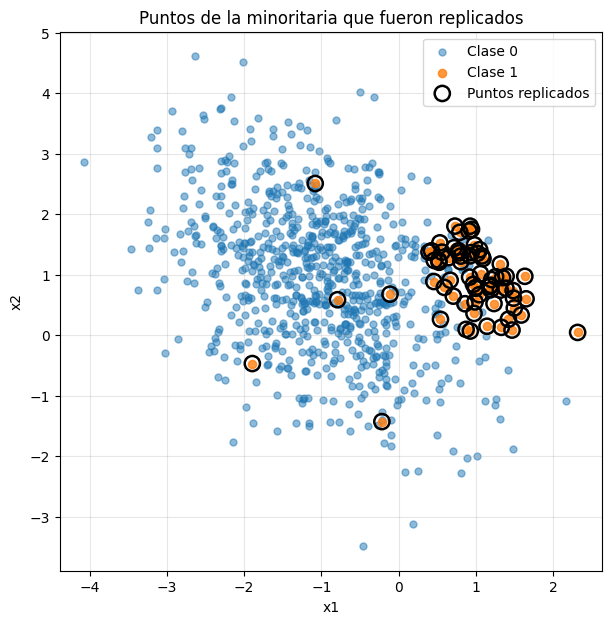

In [190]:
def plot_oversampled_points(X, y, duplicated_idx, title="Puntos duplicados por oversampling"):
    plt.figure(figsize=(7, 7))

    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=25, alpha=0.5, label="Clase 0", zorder=1)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=35, alpha=0.8, label="Clase 1", zorder=2)

    dup_unique = np.unique(duplicated_idx)
    plt.scatter(
        X[dup_unique, 0], X[dup_unique, 1],
        s=120,
        facecolors='none',
        edgecolors='black',
        linewidths=1.8,
        label="Puntos replicados",
        zorder=3
    )

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_oversampled_points(X_train, y_train, duplicated_idx, "Puntos de la minoritaria que fueron replicados")

Logistic Regression con Random Oversampling ====== 
              precision    recall  f1-score   support

           0     0.9934    0.9063    0.9479       331
           1     0.4655    0.9310    0.6207        29

    accuracy                         0.9083       360
   macro avg     0.7294    0.9187    0.7843       360
weighted avg     0.9509    0.9083    0.9215       360



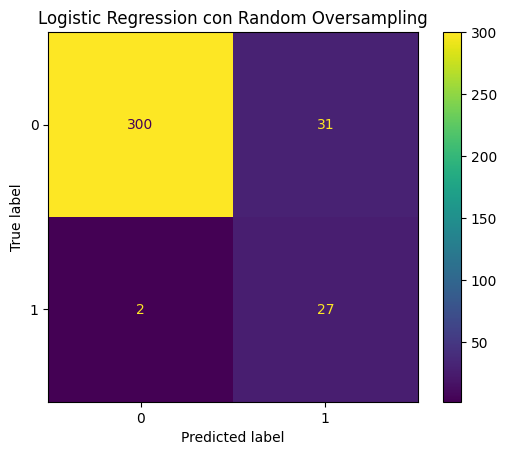

In [191]:
over_model = LogisticRegression()
evaluate_model(
    over_model,
    X_over, y_over,
    X_test, y_test,
    title="Logistic Regression con Random Oversampling"
)

In [192]:
models = {
    "Baseline": (X_train, y_train),
    "Undersampling": (X_under, y_under),
    "Tomek Links": (X_tomek, y_tomek),
    "Oversampling": (X_over, y_over)
}

for name, (Xtr, ytr) in models.items():
    print("\n" + "=" * 60)
    model = LogisticRegression()
    model.fit(Xtr, ytr)
    y_pred = model.predict(X_test)
    print(name)
    print(classification_report(y_test, y_pred, digits=4))


Baseline
              precision    recall  f1-score   support

           0     0.9672    0.9789    0.9730       331
           1     0.7200    0.6207    0.6667        29

    accuracy                         0.9500       360
   macro avg     0.8436    0.7998    0.8198       360
weighted avg     0.9473    0.9500    0.9483       360


Undersampling
              precision    recall  f1-score   support

           0     0.9933    0.8973    0.9429       331
           1     0.4426    0.9310    0.6000        29

    accuracy                         0.9000       360
   macro avg     0.7180    0.9142    0.7714       360
weighted avg     0.9490    0.9000    0.9152       360


Tomek Links
              precision    recall  f1-score   support

           0     0.9730    0.9789    0.9759       331
           1     0.7407    0.6897    0.7143        29

    accuracy                         0.9556       360
   macro avg     0.8569    0.8343    0.8451       360
weighted avg     0.9543    0.9556   

#### Imblearn

In [193]:
from imblearn.over_sampling import RandomOverSampler

In [194]:
ros = RandomOverSampler(random_state=42)
X_over_lib, y_over_lib = ros.fit_resample(X_train, y_train)

print("Distribución original   :", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución balanceada :", dict(zip(*np.unique(y_over_lib, return_counts=True))))

Distribución original   : {np.int64(0): np.int64(772), np.int64(1): np.int64(68)}
Distribución balanceada : {np.int64(0): np.int64(772), np.int64(1): np.int64(772)}


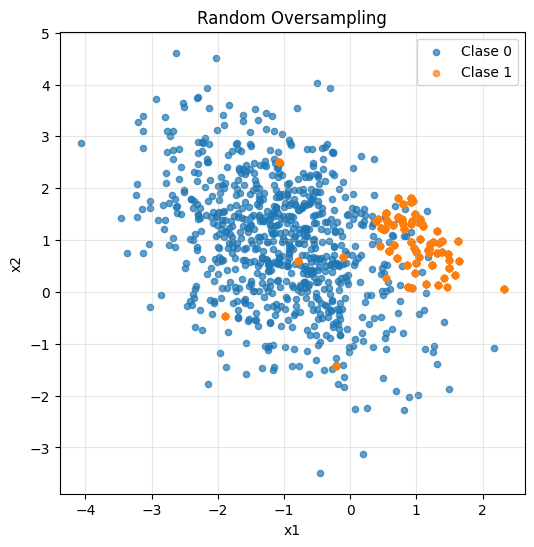

In [195]:
plot_dataset(X_over_lib, y_over_lib, "Random Oversampling")

Random Oversampling ====== 
              precision    recall  f1-score   support

           0     0.9934    0.9094    0.9495       331
           1     0.4737    0.9310    0.6279        29

    accuracy                         0.9111       360
   macro avg     0.7335    0.9202    0.7887       360
weighted avg     0.9515    0.9111    0.9236       360



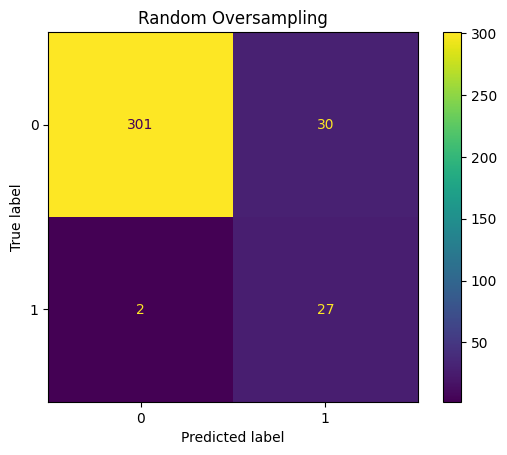

In [196]:
model_over_lib = LogisticRegression()
evaluate_model(
    model_over_lib,
    X_over_lib, y_over_lib,
    X_test, y_test,
    title="Random Oversampling"
)

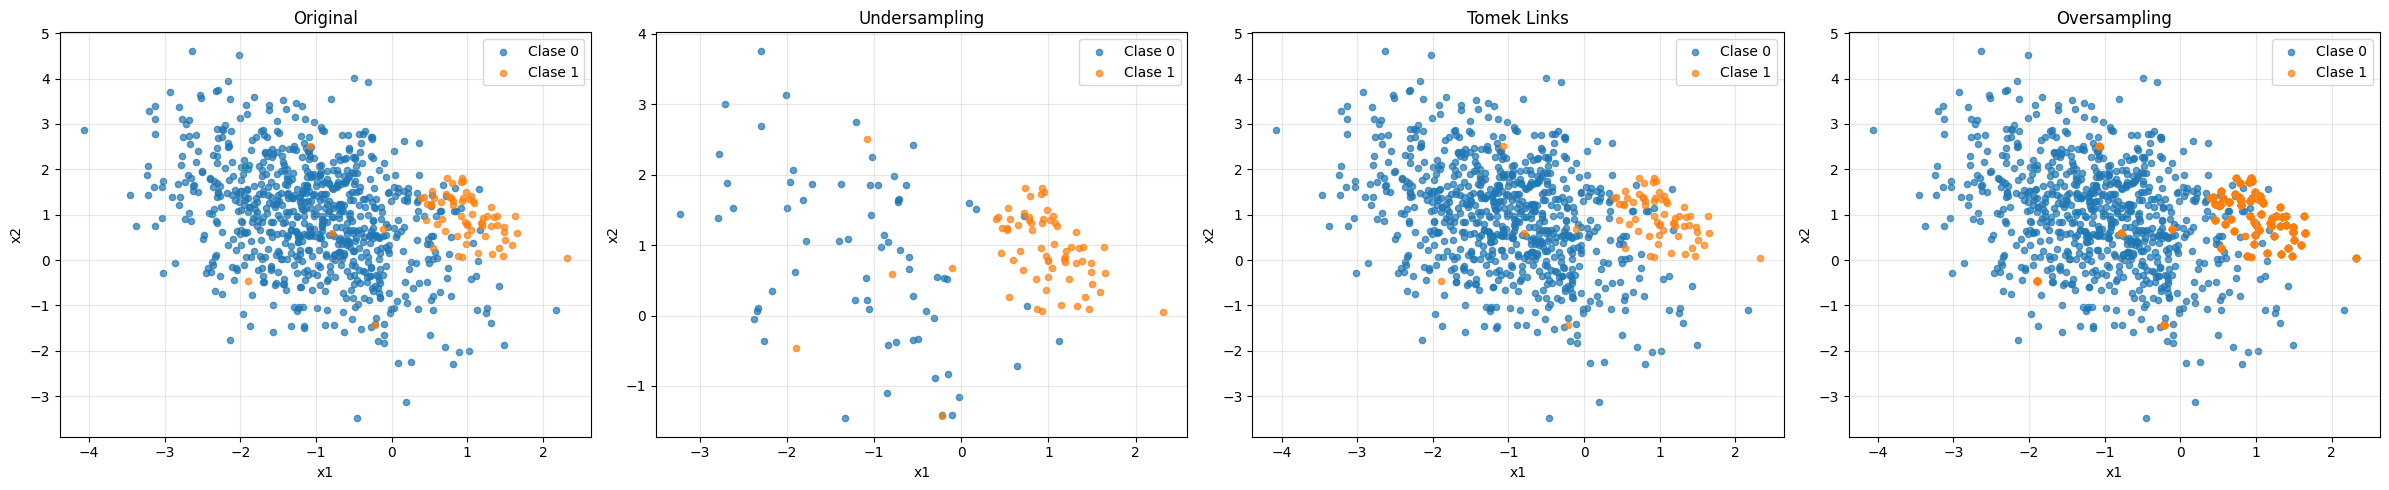

In [197]:
plt.figure(figsize=(24, 5))

plt.subplot(1, 4, 1)
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Original")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 2)
plt.scatter(X_under[y_under == 0, 0], X_under[y_under == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_under[y_under == 1, 0], X_under[y_under == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Undersampling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 3)
plt.scatter(X_tomek[y_tomek == 0, 0], X_tomek[y_tomek == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_tomek[y_tomek == 1, 0], X_tomek[y_tomek == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Tomek Links")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
plt.scatter(X_over[y_over == 0, 0], X_over[y_over == 0, 1], s=20, alpha=0.7, label="Clase 0")
plt.scatter(X_over[y_over == 1, 0], X_over[y_over == 1, 1], s=20, alpha=0.7, label="Clase 1")
plt.title("Oversampling")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Ejemplo

In [198]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

In [199]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Clases:", data.target_names)
print("Distribución original:", dict(zip(*np.unique(y, return_counts=True))))

Shape X: (569, 30)
Shape y: (569,)
Clases: ['malignant' 'benign']
Distribución original: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


In [200]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Distribución train original:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Distribución test original :", dict(zip(*np.unique(y_test, return_counts=True))))

Distribución train original: {np.int64(0): np.int64(148), np.int64(1): np.int64(250)}
Distribución test original : {np.int64(0): np.int64(64), np.int64(1): np.int64(107)}


In [201]:
rng = np.random.default_rng(42)

idx_class_0 = np.where(y_train == 0)[0]
idx_class_1 = np.where(y_train == 1)[0]

# Dejamos pocos ejemplos de la clase 0
idx_class_0_small = rng.choice(idx_class_0, size=25, replace=False)

selected_idx = np.concatenate([idx_class_0_small, idx_class_1])
rng.shuffle(selected_idx)

X_train_imb = X_train[selected_idx]
y_train_imb = y_train[selected_idx]

print("Distribución train desbalanceado:", dict(zip(*np.unique(y_train_imb, return_counts=True))))
print("Distribución test se mantiene   :", dict(zip(*np.unique(y_test, return_counts=True))))

Distribución train desbalanceado: {np.int64(0): np.int64(25), np.int64(1): np.int64(250)}
Distribución test se mantiene   : {np.int64(0): np.int64(64), np.int64(1): np.int64(107)}


In [203]:
scaler = StandardScaler()
X_train_imb_scaled = scaler.fit_transform(X_train_imb)
X_test_scaled = scaler.transform(X_test)